In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path='../output_video/cropped_player_.jpg'
# Load the image
image=cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

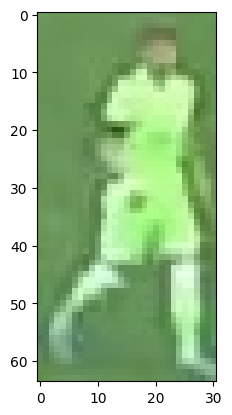

In [4]:
plt.imshow(image)
plt.show()

#take top half/shirt only

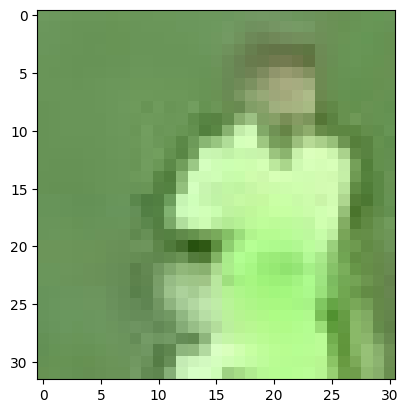

In [6]:
top_half=image[0:image.shape[0]//2,:]
plt.imshow(top_half)
plt.show()

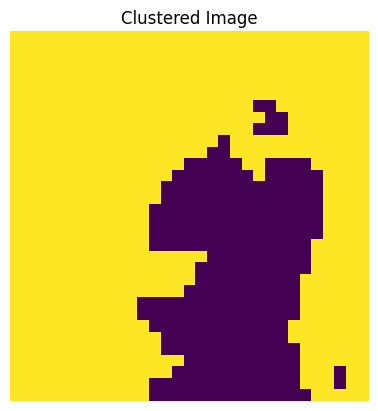

In [17]:
image_2d = top_half.reshape((-1, 3))  # flatten the top_half if it's color image (H, W, 3)

# KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# Get labels and reshape back to image dimensions
clustered_img = kmeans.labels_.reshape(top_half.shape[0], top_half.shape[1])

# Show clustered image
plt.imshow(clustered_img)  # use cmap='gray' to visualize the 2 clusters
plt.title("Clustered Image")
plt.axis('off')
plt.show()

In [25]:
corner_cluster=[clustered_img[0,0],clustered_img[0,-1],clustered_img[-1,0],clustered_img[-1,-1]]
# Get the unique cluster labels     
non_player_cluster=max(set(corner_cluster), key=corner_cluster.count)

player_cluster=1-non_player_cluster
print(player_cluster)

0


In [26]:
kmeans.cluster_centers_[player_cluster] # get the color of the player cluster

array([184.6133829 , 238.97769517, 153.52416357])